#  Exploratory Data Analysis

VyaparAI daily kirana demand data.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/vyaparai_daily_demand.csv', parse_dates=['date'])
df.drop(columns=['revenue'], inplace=True)  # revenue is target-derived, excluded from the pipeline entirely
df.head()

,date,shop_id,location_type,category,is_staple,is_perishable,day_of_week,is_weekend,is_month_end,days_to_dashain,days_to_tihar,is_dashain_window,is_tihar_window,num_transactions,units_sold
0,2020-07-01,S01,urban,cooking_essentials,1,0,Wednesday,0,1,-116,-136,0,0,7,10
1,2020-07-02,S01,urban,cooking_essentials,1,0,Thursday,0,1,-115,-135,0,0,8,10
2,2020-07-03,S01,urban,cooking_essentials,1,0,Friday,0,1,-114,-134,0,0,11,15
3,2020-07-04,S01,urban,cooking_essentials,1,0,Saturday,1,0,-113,-133,0,0,8,10
4,2020-07-05,S01,urban,cooking_essentials,1,0,Sunday,0,0,-112,-132,0,0,11,15


## Shape, date range, missing values

In [10]:
print(df.shape)
print(df['date'].min(), '->', df['date'].max())
print(df.isna().sum())

(141312, 15)
2020-07-01 00:00:00 -> 2026-07-17 00:00:00
date                 0
shop_id              0
location_type        0
category             0
is_staple            0
is_perishable        0
day_of_week          0
is_weekend           0
is_month_end         0
days_to_dashain      0
days_to_tihar        0
is_dashain_window    0
is_tihar_window      0
num_transactions     0
units_sold           0
dtype: int64


## Demand distribution by category and shop

In [11]:
df.groupby('category')['units_sold'].describe()

,count,mean,std,min,25%,50%,75%,max
category,,,,,,,,
cooking_essentials,17664.0,9.603091,4.827021,0.0,6.0,9.0,12.0,48.0
dairy,17664.0,15.932405,7.606874,0.0,10.0,15.0,21.0,58.0
fresh_bakery,17664.0,12.545063,6.117062,0.0,8.0,12.0,16.0,40.0
grains_pulses,17664.0,12.636096,6.173962,0.0,8.0,12.0,17.0,43.0
household_personal_care,17664.0,8.108299,4.038047,0.0,5.0,8.0,11.0,32.0
puja_items,17664.0,5.948087,4.718429,0.0,3.0,5.0,7.0,71.0
snacks_biscuits_confectionery,17664.0,19.702615,9.768558,0.0,13.0,18.0,25.0,97.0
sweets_mithai,17664.0,5.752491,3.807726,0.0,4.0,5.0,7.0,45.0


In [12]:
df.groupby('shop_id')['units_sold'].mean().sort_values(ascending=False)

shop_id
S02    16.567991
S01    14.618433
S08    13.662591
S05    11.706239
S03    10.678555
S04     9.800442
S06     6.983865
S07     6.210032
Name: units_sold, dtype: float64

## Weekly seasonality (Saturday = Nepali weekend)

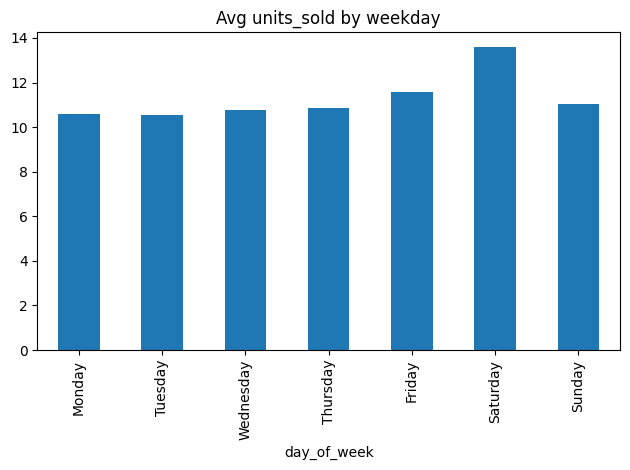

In [13]:
df.groupby('day_of_week')['units_sold'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', title='Avg units_sold by weekday')
plt.tight_layout()

## Festival effect (Dashain / Tihar windows)

In [14]:
df.groupby('is_dashain_window')['units_sold'].mean()

is_dashain_window
0    11.105052
1    14.651476
Name: units_sold, dtype: float64

In [15]:
df.groupby('is_tihar_window')['units_sold'].mean()

is_tihar_window
0    11.074115
1    15.253038
Name: units_sold, dtype: float64

## Overall daily demand trend (single shop-category, for readability)

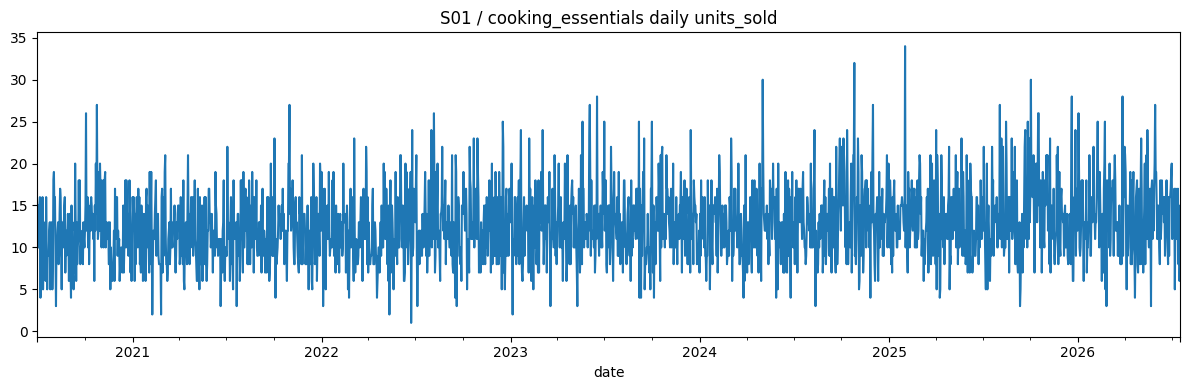

In [16]:
sub = df[(df.shop_id=='S01') & (df.category=='cooking_essentials')].sort_values('date')
sub.set_index('date')['units_sold'].plot(figsize=(12,4), title='S01 / cooking_essentials daily units_sold')
plt.tight_layout()